# #30DayMapChallenge - Día 5: Analog Map
## Caso de Negocio: Del croquis de campo al GIS operativo

**Autor:** Mario Ignacio Ibañez Castro | **Rol:** Data Scientist & Strategic Planner

### El objetivo
El equipo comercial visita un local en **Condesa** y regresa con un croquis a mano: calles, un parque y una equis roja que dice *"aquí"*. No hay GPS. No hay shapefile. Solo papel.

Hoy el reto es **georreferenciar esa imagen escaneada**: transformar píxeles en coordenadas reales para que el croquis entre al mismo stack que DENUE, ruteo y dashboards.

**Pregunta de negocio:** ¿Podemos convertir un croquis de visita en una ubicación accionable (lat/lon) sin volver al campo?

**Reto técnico:** Georreferenciación de imagen escaneada con Ground Control Points (GCPs).

**Fuente de Datos:** Manual / propio — croquis sintético de campo (`00_Datos/croquis_condesa_campo.png`) + GCPs medidos sobre el papel.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from pathlib import Path
from PIL import Image

import rasterio
from rasterio.control import GroundControlPoint
from rasterio.transform import from_gcps
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.io import MemoryFile

plt.style.use('dark_background')
%matplotlib inline

RUTA_DATOS = Path('../00_Datos')
CARPETA_SALIDA = Path('.')
CROQUIS = RUTA_DATOS / 'croquis_condesa_campo.png'
GCPS_CSV = RUTA_DATOS / 'gcps_croquis.csv'

### 1. El análogo: inspeccionar el croquis
Antes de georreferenciar, entendemos qué llegó de campo: una imagen, no una tabla.

Tamaño: 1000 x 800 px | Modo: RGB


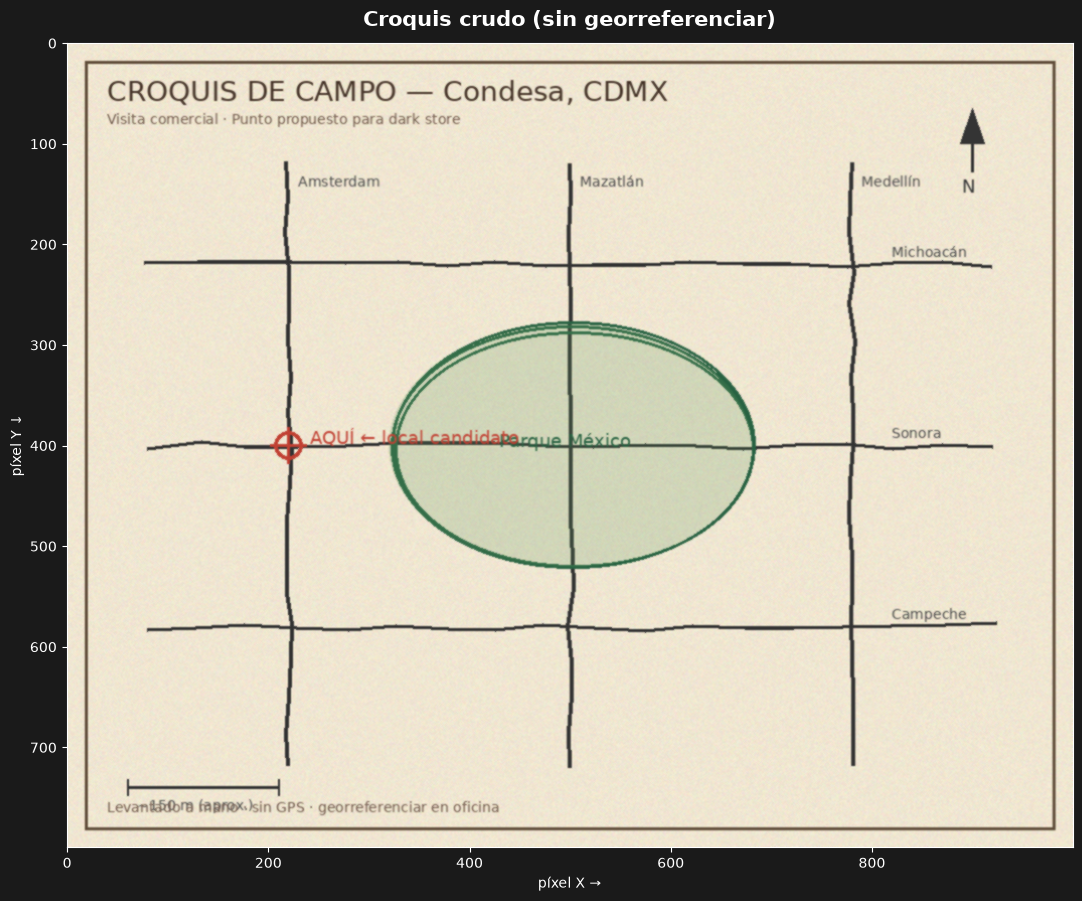

Guardado: Dia5_Croquis_Crudo.png


In [2]:
img = Image.open(CROQUIS)
print(f'Tamaño: {img.size[0]} x {img.size[1]} px | Modo: {img.mode}')

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#1a1a1a')
ax.imshow(img)
ax.set_title('Croquis crudo (sin georreferenciar)', fontsize=15, fontweight='bold', color='white', pad=12)
ax.set_xlabel('píxel X →', color='white')
ax.set_ylabel('píxel Y ↓', color='white')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig(CARPETA_SALIDA / 'Dia5_Croquis_Crudo.png', dpi=160, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia5_Croquis_Crudo.png')

### 2. Ground Control Points (GCPs)
Los GCPs son el puente entre el papel y el planeta: pares `(píxel_x, píxel_y) ↔ (lon, lat)`.

En campo real se toman con GPS diferencial o midiendo esquinas conocidas (intersecciones, monumentos). Aquí usamos puntos de control definidos sobre el croquis de Condesa.

,nombre,pixel_x,pixel_y,longitud,latitud
0,esquina_NO,0,0,-99.178000,19.420000
1,esquina_NE,999,0,-99.165000,19.420000
2,esquina_SO,0,799,-99.178000,19.408000
3,esquina_SE,999,799,-99.165000,19.408000
4,amsterdam_sonora,220,400,-99.175137,19.413992
5,mazatlan_michoacan,500,220,-99.171493,19.416696
6,medellin_campeche,780,580,-99.167850,19.411289
7,parque_centro,500,400,-99.171493,19.413992


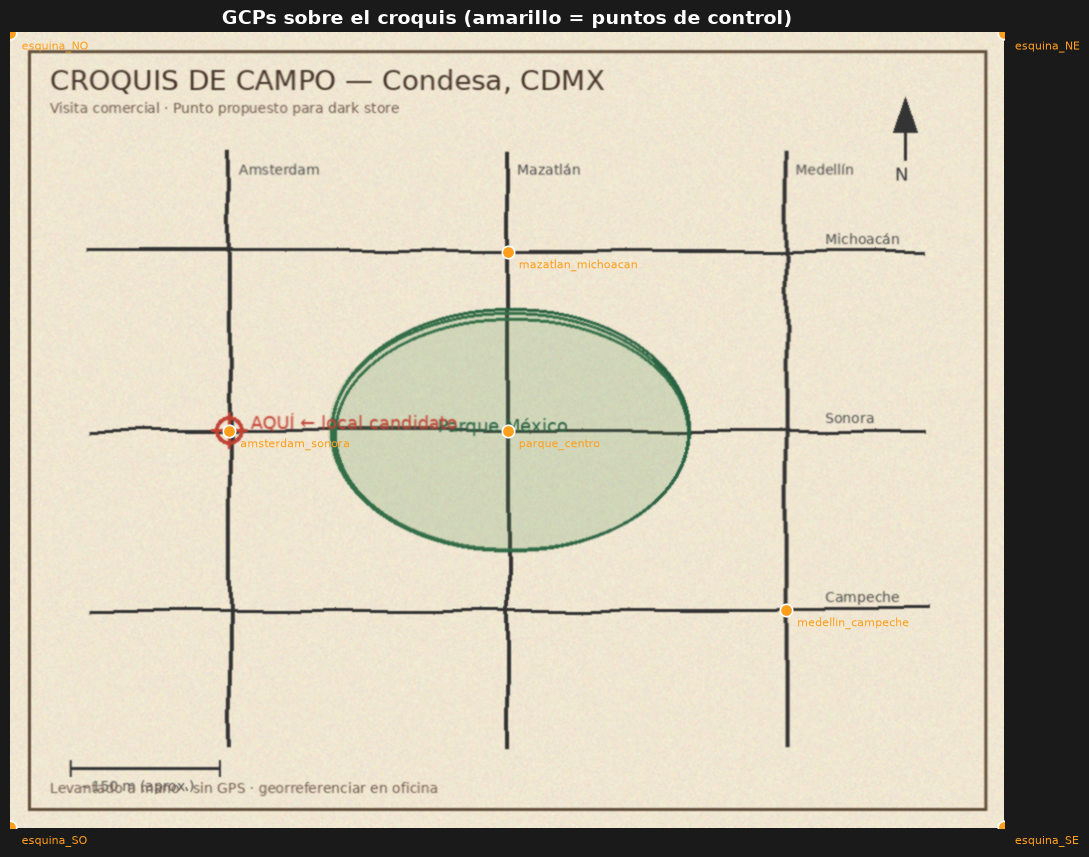

Guardado: Dia5_GCPs_Sobre_Croquis.png


In [3]:
gcps_df = pd.read_csv(GCPS_CSV)
display(gcps_df)

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#1a1a1a')
ax.imshow(img)
ax.scatter(
    gcps_df['pixel_x'], gcps_df['pixel_y'],
    s=80, c='#FF9F1C', edgecolors='white', linewidths=1.2, zorder=3
)
for _, r in gcps_df.iterrows():
    ax.annotate(
        r['nombre'],
        (r['pixel_x'], r['pixel_y']),
        textcoords='offset points',
        xytext=(8, -12),
        fontsize=8,
        color='#FF9F1C'
    )
ax.set_title('GCPs sobre el croquis (amarillo = puntos de control)', fontsize=14, fontweight='bold', color='white')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(CARPETA_SALIDA / 'Dia5_GCPs_Sobre_Croquis.png', dpi=160, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia5_GCPs_Sobre_Croquis.png')

### 3. Construir la transformación affine
Con los GCPs, `rasterio` estima una transformación que convierte columnas/filas de la imagen en coordenadas geográficas (EPSG:4326).

In [4]:
# rasterio: GroundControlPoint(col, row, x, y)  →  x=lon, y=lat
gcps = [
    GroundControlPoint(
        col=float(r.pixel_x),
        row=float(r.pixel_y),
        x=float(r.longitud),
        y=float(r.latitud),
        z=0.0,
        id=str(r.nombre),
    )
    for r in gcps_df.itertuples()
]

transform = from_gcps(gcps)
print('Affine transform (pixel → lon/lat):')
print(transform)

# Validación rápida: proyectar un GCP de vuelta
col0, row0 = float(gcps_df.iloc[4].pixel_x), float(gcps_df.iloc[4].pixel_y)
lon0, lat0 = transform * (col0, row0)
print(f"\nCheck GCP 'amsterdam_sonora':")
print(f'  esperado: ({gcps_df.iloc[4].longitud}, {gcps_df.iloc[4].latitud})')
print(f'  obtenido: ({lon0:.6f}, {lat0:.6f})')

Affine transform (pixel → lon/lat):
| 0.00,-0.00,-99.18|
| 0.00,-0.00, 19.42|
| 0.00, 0.00, 1.00|

Check GCP 'amsterdam_sonora':
  esperado: (-99.175137, 19.413992)
  obtenido: (-99.175137, 19.413992)


### 4. Crear el GeoTIFF georreferenciado
Escribimos el croquis como raster geográfico y lo reproyectamos a Web Mercator (EPSG:3857) para superponerlo sobre un mapa base.

In [5]:
arr = np.array(img.convert('RGBA'))
height, width = arr.shape[0], arr.shape[1]

# Separar bandas RGBA
bands = [arr[:, :, i] for i in range(4)]

profile_4326 = {
    'driver': 'GTiff',
    'height': height,
    'width': width,
    'count': 4,
    'dtype': 'uint8',
    'crs': 'EPSG:4326',
    'transform': transform,
    'nodata': 0,
}

geotiff_path = RUTA_DATOS / 'croquis_condesa_georef_4326.tif'
with rasterio.open(geotiff_path, 'w', **profile_4326) as dst:
    for i, band in enumerate(bands, start=1):
        dst.write(band, i)

print(f'GeoTIFF EPSG:4326: {geotiff_path}')

# Reproyectar a Web Mercator para basemap
with rasterio.open(geotiff_path) as src:
    transform_3857, width_3857, height_3857 = calculate_default_transform(
        src.crs, 'EPSG:3857', src.width, src.height, *src.bounds
    )
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': 'EPSG:3857',
        'transform': transform_3857,
        'width': width_3857,
        'height': height_3857,
    })

    geotiff_3857 = RUTA_DATOS / 'croquis_condesa_georef_3857.tif'
    with rasterio.open(geotiff_3857, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform_3857,
                dst_crs='EPSG:3857',
                resampling=Resampling.bilinear,
            )

print(f'GeoTIFF EPSG:3857: {geotiff_3857}')

GeoTIFF EPSG:4326: ../00_Datos/croquis_condesa_georef_4326.tif


GeoTIFF EPSG:3857: ../00_Datos/croquis_condesa_georef_3857.tif


### 5. Extraer el punto de negocio
La equis del croquis (Amsterdam × Sonora) ahora tiene coordenadas reales. Eso es lo que operaciones necesita para visitar, rutar o contrastar con DENUE.

In [6]:
# POI del croquis: píxel aproximado de la equis roja
poi_px = (220, 400)
poi_lon, poi_lat = transform * poi_px

gdf_poi = gpd.GeoDataFrame(
    [{'nombre': 'Local candidato (croquis)', 'origen': 'georreferenciado'}],
    geometry=gpd.points_from_xy([poi_lon], [poi_lat]),
    crs='EPSG:4326'
)
gdf_poi_web = gdf_poi.to_crs(epsg=3857)

print('Punto de negocio georreferenciado:')
print(f'  Longitud: {poi_lon:.6f}')
print(f'  Latitud:  {poi_lat:.6f}')
display(gdf_poi)

Punto de negocio georreferenciado:
  Longitud: -99.175137
  Latitud:  19.413992


,nombre,origen,geometry
0,Local candidato (croquis),georreferenciado,POINT (-99.17514 19.41399)


### 6. El mapa: croquis anclado al mundo real
Superponemos el raster georreferenciado sobre un basemap. El papel deja de ser decoración: es una capa GIS.

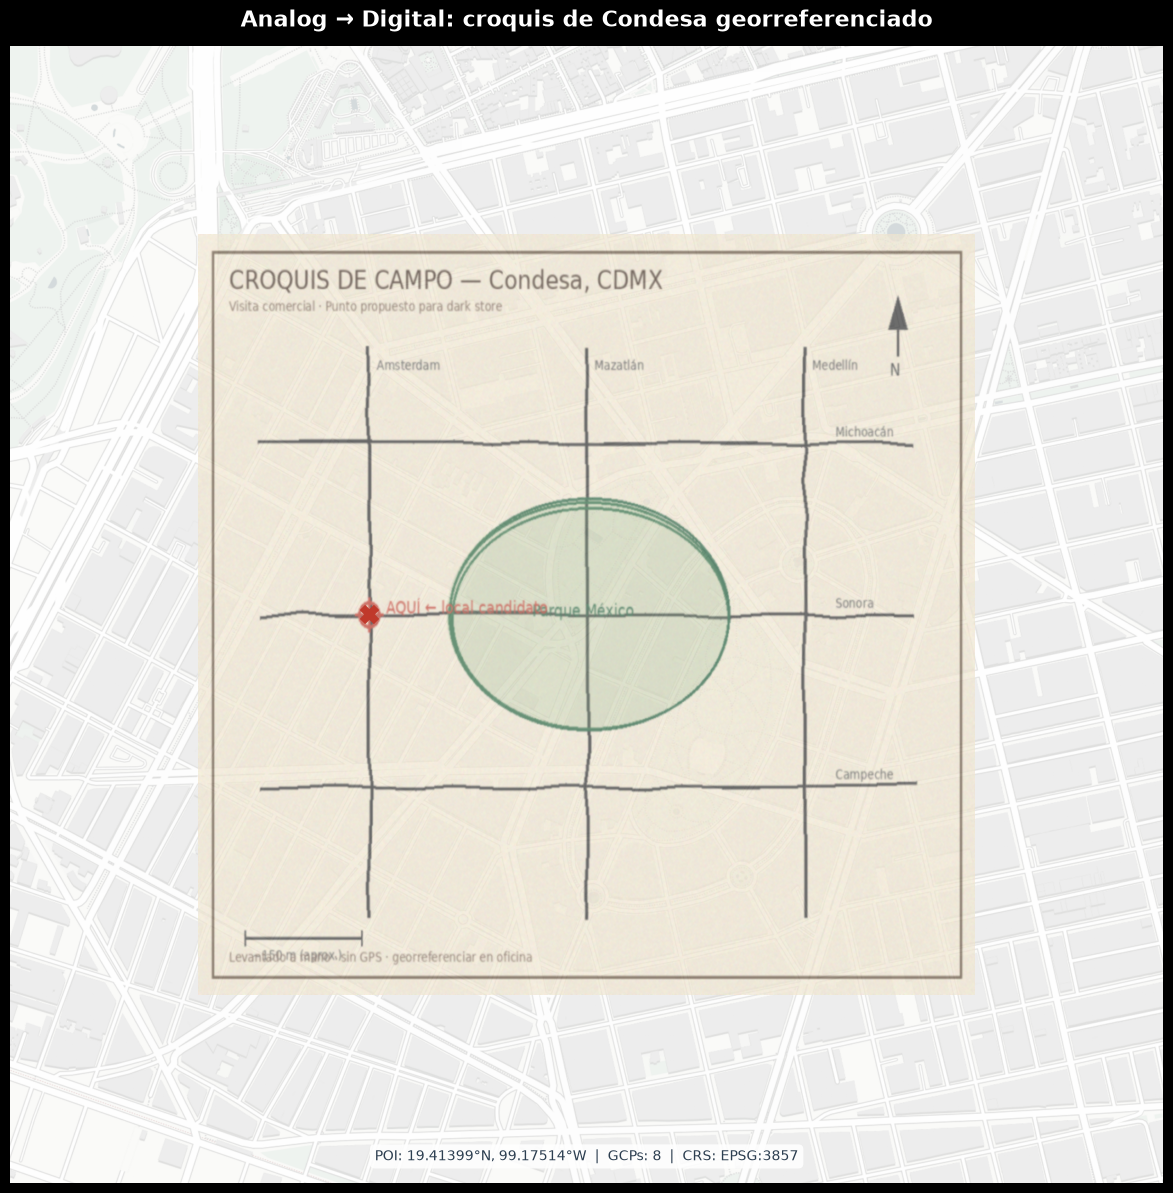

Guardado: Dia5_Croquis_Georeferenciado.png


In [7]:
with rasterio.open(geotiff_3857) as src:
    rgba = src.read([1, 2, 3, 4])
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    # matplotlib espera (H, W, 4)
    rgba_img = np.transpose(rgba, (1, 2, 0))

fig, ax = plt.subplots(figsize=(12, 12))
fig.patch.set_facecolor('black')

# Basemap urbano
pad = 350  # metros aprox en Web Mercator
ax.set_xlim(extent[0] - pad, extent[1] + pad)
ax.set_ylim(extent[2] - pad, extent[3] + pad)

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.PositronNoLabels,
        zoom_adjust=1,
        attribution=False,
        zorder=1
    )
except Exception as e:
    print(f'Basemap no disponible ({e}).')

# Croquis con transparencia
ax.imshow(
    rgba_img,
    extent=extent,
    origin='upper',
    alpha=0.72,
    zorder=2,
    interpolation='bilinear'
)

# POI
gdf_poi_web.plot(
    ax=ax,
    markersize=160,
    color='#C0392B',
    marker='X',
    zorder=4,
    label='Local candidato'
)

ax.set_axis_off()
ax.set_title(
    'Analog → Digital: croquis de Condesa georreferenciado',
    fontsize=16,
    fontweight='bold',
    color='white',
    pad=14
)
ax.text(
    0.5, 0.02,
    f'POI: {poi_lat:.5f}°N, {abs(poi_lon):.5f}°W  |  GCPs: {len(gcps_df)}  |  CRS: EPSG:3857',
    transform=ax.transAxes,
    ha='center',
    fontsize=10,
    color='#2C3E50',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='none')
)

plt.tight_layout()
plt.savefig(CARPETA_SALIDA / 'Dia5_Croquis_Georeferenciado.png', dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia5_Croquis_Georeferenciado.png')

### 7. Antes vs Después
El valor no es "hacerlo ver bonito": es **desbloquear** un activo analógico para el stack digital.

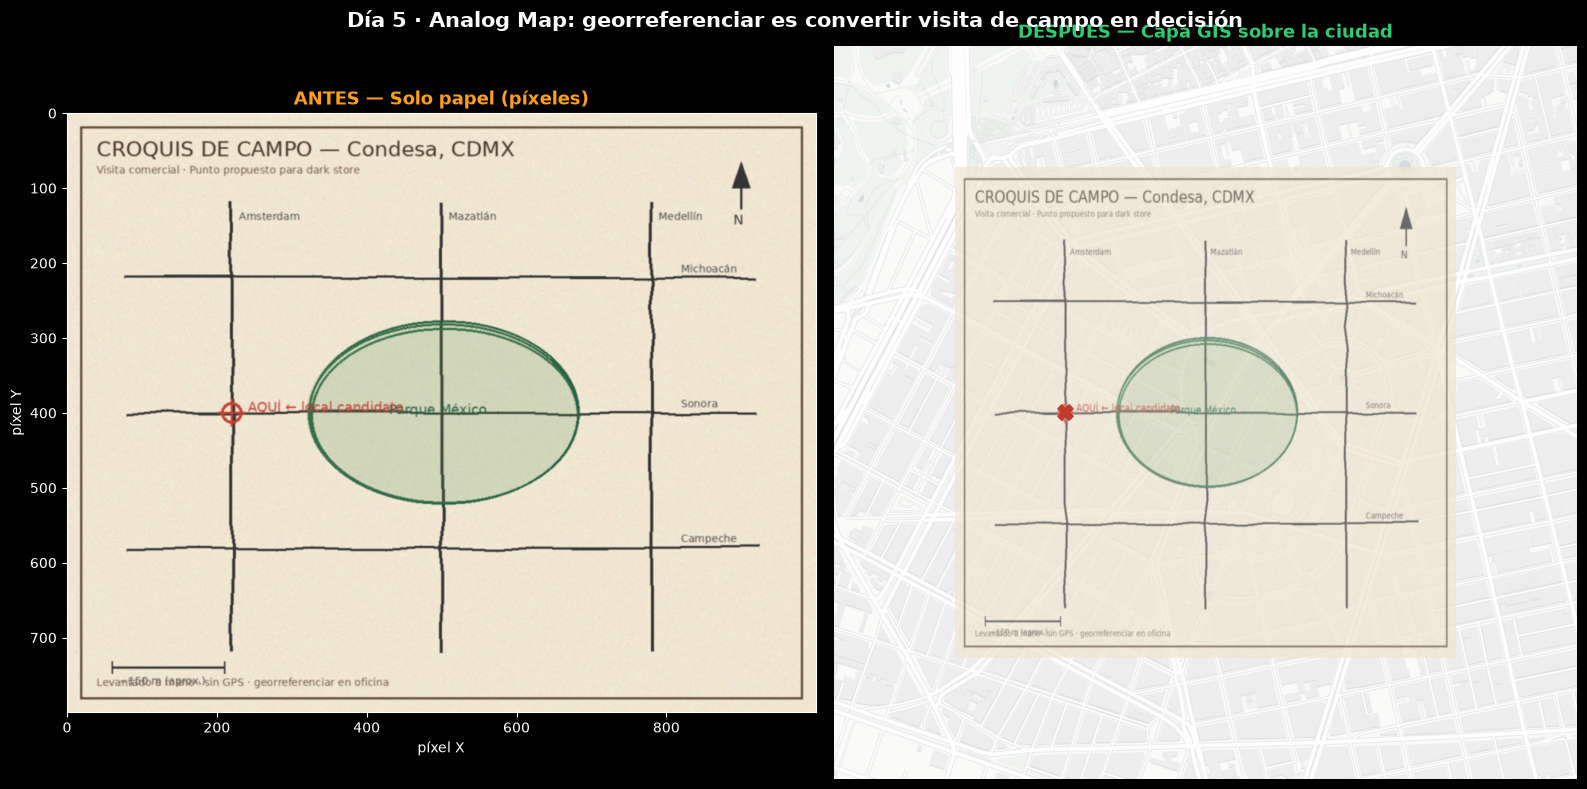

Guardado: Dia5_Antes_vs_Despues.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('black')

# Antes
ax0 = axes[0]
ax0.imshow(img)
ax0.set_title('ANTES — Solo papel (píxeles)', fontsize=13, fontweight='bold', color='#FF9F1C')
ax0.set_xlabel('píxel X', color='white')
ax0.set_ylabel('píxel Y', color='white')
ax0.tick_params(colors='white')

# Después
ax1 = axes[1]
ax1.set_xlim(extent[0] - pad, extent[1] + pad)
ax1.set_ylim(extent[2] - pad, extent[3] + pad)
try:
    ctx.add_basemap(ax1, source=ctx.providers.CartoDB.PositronNoLabels, zoom_adjust=1, attribution=False, zorder=1)
except Exception:
    pass
ax1.imshow(rgba_img, extent=extent, origin='upper', alpha=0.72, zorder=2, interpolation='bilinear')
gdf_poi_web.plot(ax=ax1, markersize=120, color='#C0392B', marker='X', zorder=4)
ax1.set_axis_off()
ax1.set_title('DESPUÉS — Capa GIS sobre la ciudad', fontsize=13, fontweight='bold', color='#2ECC71')

fig.suptitle(
    'Día 5 · Analog Map: georreferenciar es convertir visita de campo en decisión',
    fontsize=15,
    fontweight='bold',
    color='white',
    y=0.98
)

plt.tight_layout()
plt.savefig(CARPETA_SALIDA / 'Dia5_Antes_vs_Despues.png', dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia5_Antes_vs_Despues.png')

### 8. Insight de negocio
Un croquis sin georreferenciar vive en WhatsApp y se pierde. Georreferenciado:

1. Entra al mismo mapa que competencia (DENUE) y tráfico.
2. Permite medir distancia a Parque México, metro, o dark stores vecinas.
3. Documenta la visita comercial con coordenadas auditables.

**Regla práctica:** todo croquis de campo debería nacer con al menos **3–4 GCPs** (esquinas o intersecciones conocidas). Sin ellos, el papel no escala.

### Regenerar el croquis
```bash
python ../00_Datos/generarCroquis.py
```

In [9]:
# Exportar POI para días posteriores / operaciones
poi_csv = RUTA_DATOS / 'poi_local_candidato.csv'
gdf_poi.drop(columns='geometry').assign(longitud=poi_lon, latitud=poi_lat).to_csv(poi_csv, index=False)
print(f'POI exportado: {poi_csv}')
print('Día 5 completado.')

POI exportado: ../00_Datos/poi_local_candidato.csv
Día 5 completado.
